In [1]:
# import qiskit_aer

# from ewfs.setting import SETTING_PAIRS
# from ewfs.experiment import run_experiment
# from qiskit_ibm_runtime.fake_provider import FakeFez

# backend = qiskit_aer.Aer.get_backend("aer_simulator")
# backend = FakeFez()

# run_experiment(
#     shots=10_000,
#     num_trials=1,
#     charlie_sizes=range(1, 2),
#     debbie_sizes=[0],
#     strategy="majority_vote",
#     friend_state="ghz",
#     flag_size=6,
#     backend=backend,
#     settings=SETTING_PAIRS,
#     save=True,
# )

In [2]:
# from ewfs.setting import SETTING_PAIRS
# from ewfs.experiment import run_experiment

# from qiskit_ibm_runtime import QiskitRuntimeService
 
# QiskitRuntimeService.save_account(
#   token="htVYX3nZDI5I1fSkYQw8Y0rddMrBi1eElvW8EHhy5D4q",
#   name="farrokh",
#   channel="ibm_quantum_platform",
#   overwrite=True
# )
# service = QiskitRuntimeService(name="farrokh")
# backend = service.backend("ibm_pittsburgh")


# run_experiment(
#     shots=10_000,
#     num_trials=1,
#     charlie_sizes=range(1, 2),
#     debbie_sizes=[0],
#     strategy="majority_vote",
#     friend_state="ghz",
#     flag_size=6,
#     backend=backend,
#     settings=SETTING_PAIRS,
#     save=True,
# )

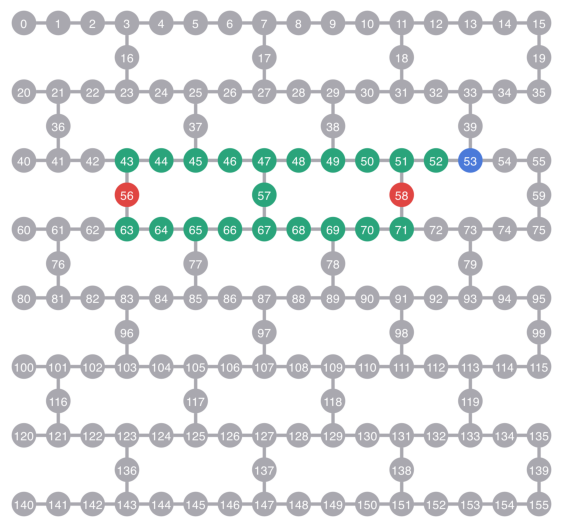

In [3]:
from ewfs.ghz import plot_ghz_fez
from qiskit_ibm_runtime.fake_provider import FakeFez

coupling_map = FakeFez().coupling_map

def remove_elements(source_list, elements_to_remove):
    return [item for item in source_list if item not in elements_to_remove]

layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]

flags = [56, 58]

start_qubit = layout[0]

plot_ghz_fez(coupling_map=coupling_map, data_qubits=remove_elements(layout, flags), flag_qubits=flags, start_qubit=start_qubit)

In [4]:
"""Extended Wigner's friend scenario (EWFS)" functionality."""

from qiskit import QuantumCircuit

from ewfs.observer import DEFAULT_ANGLES, DEFAULT_BETA
from ewfs.setting import PEEK, REVERSE_1, REVERSE_2

from qiskit_ibm_runtime.fake_provider import FakeFez
backend = FakeFez()
coupling_map = backend.coupling_map


class Friend:
    def __init__(self, size: int, qubits: list[int], label: str) -> None:
        """Initialize the friend.

        Attributes:
            size: The size of the friend's subsystem.
            qubits: The indices of the qubits in the friend's subsystem.
            label: The label of the friend.
        """
        self.size = size
        self.qubits = qubits
        self.label = label


class EWFS:
    def __init__(
        self,
        alice_setting: str,
        bob_setting: str,
        coupling_map: list,
        layout: list,
        flag_qubits: list,
        angles: dict[str, float] | None = None,
        beta: float | None = None,
    ) -> None:
        """Initialize the extended Wigner's friend scenario."""
        # Settings for Alice and Bob.
        self.alice_setting = alice_setting
        self.bob_setting = bob_setting

        self.coupling_map = coupling_map
        self.layout = layout
        self.flag_qubits = flag_qubits
        self.data_qubits = self._remove_elements(layout, flag_qubits)
        self.layout_dict = dict(zip(layout, range(len(layout))))

        self.alice = self.layout_dict[self.layout[1]] #hardcoded
        self.bob = self.layout_dict[self.layout[0]]

        self.charlie_qubits = [self.layout_dict[self.data_qubits[i]] for i in range(2, len(self.data_qubits))] # the first two qubits should always be the system qubits
        self.charlie_size = len(self.charlie_qubits)

        self.sys_size = 2
        self.meas_size = 2

        # Angles for Alice and Bob measurements.
        self.angles = angles or DEFAULT_ANGLES
        self.beta = beta or DEFAULT_BETA

    def circuit(self) -> QuantumCircuit:
        """Generate the circuit for extended Wigner's friend scenario."""
        # Initialize system qubits and entangle with Charlie
        qc = self._initialize_circuit()

        alice_creg, bob_creg, flag_creg = self._get_classical_registers()
        print(alice_creg, bob_creg, flag_creg)

        charlie = Friend(
            size=self.charlie_size, qubits=self.charlie_qubits, label="Charlie"
        )

        # Apply the setting for Alice/Charlie.
        self._apply_setting(
            qc=qc,
            observer=self.alice,
            setting=self.alice_setting,
            angle=self.angles[self.alice_setting],
            observer_creg=alice_creg,
            friend=charlie,
        )
        # Apply the setting for Bob.
        self._apply_setting(
            qc=qc,
            observer=self.bob,
            setting=self.bob_setting,
            angle=(self.beta - self.angles[self.bob_setting]),
            observer_creg=bob_creg,
            friend=None,
        )

        # Finally, measure the flag qubits
        flag_qubits = [self.layout_dict[flag] for flag in self.flag_qubits]
        qc.measure(flag_qubits, flag_creg)

        return qc
    
    def _ghz(self, qc):
        visited = [self.data_qubits[0]]
        
        for i in range(1, len(self.data_qubits)):
            neighbors = self.coupling_map.neighbors(self.data_qubits[i])
            for qubit in neighbors:
                if qubit not in visited and qubit in self.data_qubits:
                    qc.cx(self.layout_dict[self.data_qubits[i]], self.layout_dict[qubit])
                    visited.append(qubit)
            visited.append(self.data_qubits[i])
    
    def _ghz_inverse(self, qc):
        # implement the inverse of the ghz operations
        data_qubits = self.data_qubits[::-1]
        visited = [data_qubits[-1]]
        
        for i in range(len(data_qubits)):
            neighbors = self.coupling_map.neighbors(data_qubits[i])
            for qubit in neighbors:
                if qubit not in visited and qubit in data_qubits:
                    qc.cx(self.layout_dict[qubit], self.layout_dict[data_qubits[i]])
                    visited.append(qubit)
            visited.append(data_qubits[i])

    def _flag_operations(self, qc):
        for flag in self.flag_qubits:
            neighbors = self.coupling_map.neighbors(flag)
            for qubit in neighbors:
                qc.cx(self.layout_dict[qubit], self.layout_dict[flag])

    def _flag_operations_inverse(self, qc):
        # implement the inverse of the flag operations
        flag_qubits = self.flag_qubits[::-1]
        for flag in flag_qubits:
            neighbors = self.coupling_map.neighbors(flag)
            neighbors = neighbors[::-1]
            for qubit in neighbors:
                qc.cx(self.layout_dict[flag], self.layout_dict[qubit])
    
    def _remove_elements(self, source_list, elements_to_remove):
        return [item for item in source_list if item not in elements_to_remove]

    def _initialize_circuit(self) -> QuantumCircuit:
        """Initialize the classical measurement registers based on the strategy."""
        if self.alice_setting == PEEK:
            meas_size = self.charlie_size + 1
        else:
            meas_size = 2
        meas_size += len(self.flag_qubits)
        
        # measurement = ClassicalRegister(size, name="measurement")

        qc = QuantumCircuit(len(self.layout), meas_size)

        # first create entanglement between the system qubits
        
        self._prepare_bipartite_system(qc, self.alice, self.bob)

        # Perform the rotations for Alice and Bob based on their settings.
        self._ewfs_rotation(qc, self.alice, self.angles[PEEK])
        self._ewfs_rotation(qc, self.bob, self.beta - self.angles[PEEK])

        # then create the ghz state on the data qubits (layout\flags)
        self._ghz(qc)

        # now implement the check operations
        self._flag_operations(qc)
        
        return qc
        
    def _get_classical_registers(self) -> tuple:
        """Define the classical registers for the observers and the flag register."""
        if self.alice_setting is PEEK and self.bob_setting is not PEEK:
            alice_creg = list(range(self.charlie_size))
            bob_creg = [self.charlie_size]
        else:
            alice_creg, bob_creg = [0], [1]

        flag_creg = list(range(bob_creg[0] + 1, bob_creg[0] + 1 + len(self.flag_qubits)))

        return alice_creg, bob_creg, flag_creg
        

    def _prepare_bipartite_system(self, qc: QuantumCircuit, alice: int, bob: int) -> None:
        """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
        qc.x(alice)
        qc.x(bob)
        qc.h(alice)
        qc.cx(alice, bob)

    def _apply_setting(
        self,
        qc: QuantumCircuit,
        observer: int,
        setting: str,
        angle: float,
        observer_creg: list[int],
        friend: Friend | None,
    ):
        """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
        if setting is PEEK:
            self._apply_peek(qc, observer, observer_creg, friend)
        elif setting in [REVERSE_1, REVERSE_2]:
            self._apply_reverse(qc, observer, observer_creg, friend, angle)

    def _apply_peek(self, qc: QuantumCircuit, observer: int, observer_creg: list[int], friend: Friend) -> None:
        # Ask friend for the outcome.
        qc.measure(friend.qubits, observer_creg)

    def _apply_reverse(
        self,
        qc: QuantumCircuit,
        observer: int,
        observer_creg: list[int],
        friend: Friend | None,
        angle: float,
    ) -> None:
        
        if friend is not None:
            qc.barrier(observer, friend.qubits)
            # do the inverse of ghz() function
            self._flag_operations_inverse(qc)
            self._ghz_inverse(qc)

        # Apply the rotation based on the observer.
        if observer is self.alice:
            self._ewfs_rotation(qc, observer, self.angles[PEEK], invert=False)
        if observer is self.bob:
            self._ewfs_rotation(qc, observer, self.beta - self.angles[PEEK], invert=False)

        # Apply a rotation.
        self._ewfs_rotation(qc, observer, angle)

        qc.measure(observer, observer_creg)

    def _ewfs_rotation(self, qc: QuantumCircuit, observer: int, angle: float, invert: bool = True) -> None:
        """Apply an EWFS-specific rotation to a qubit."""
        if invert:
            qc.rz(-angle, observer)
            qc.h(observer)
        else:
            qc.h(observer)
            qc.rz(angle, observer)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18] [19] [20, 21]


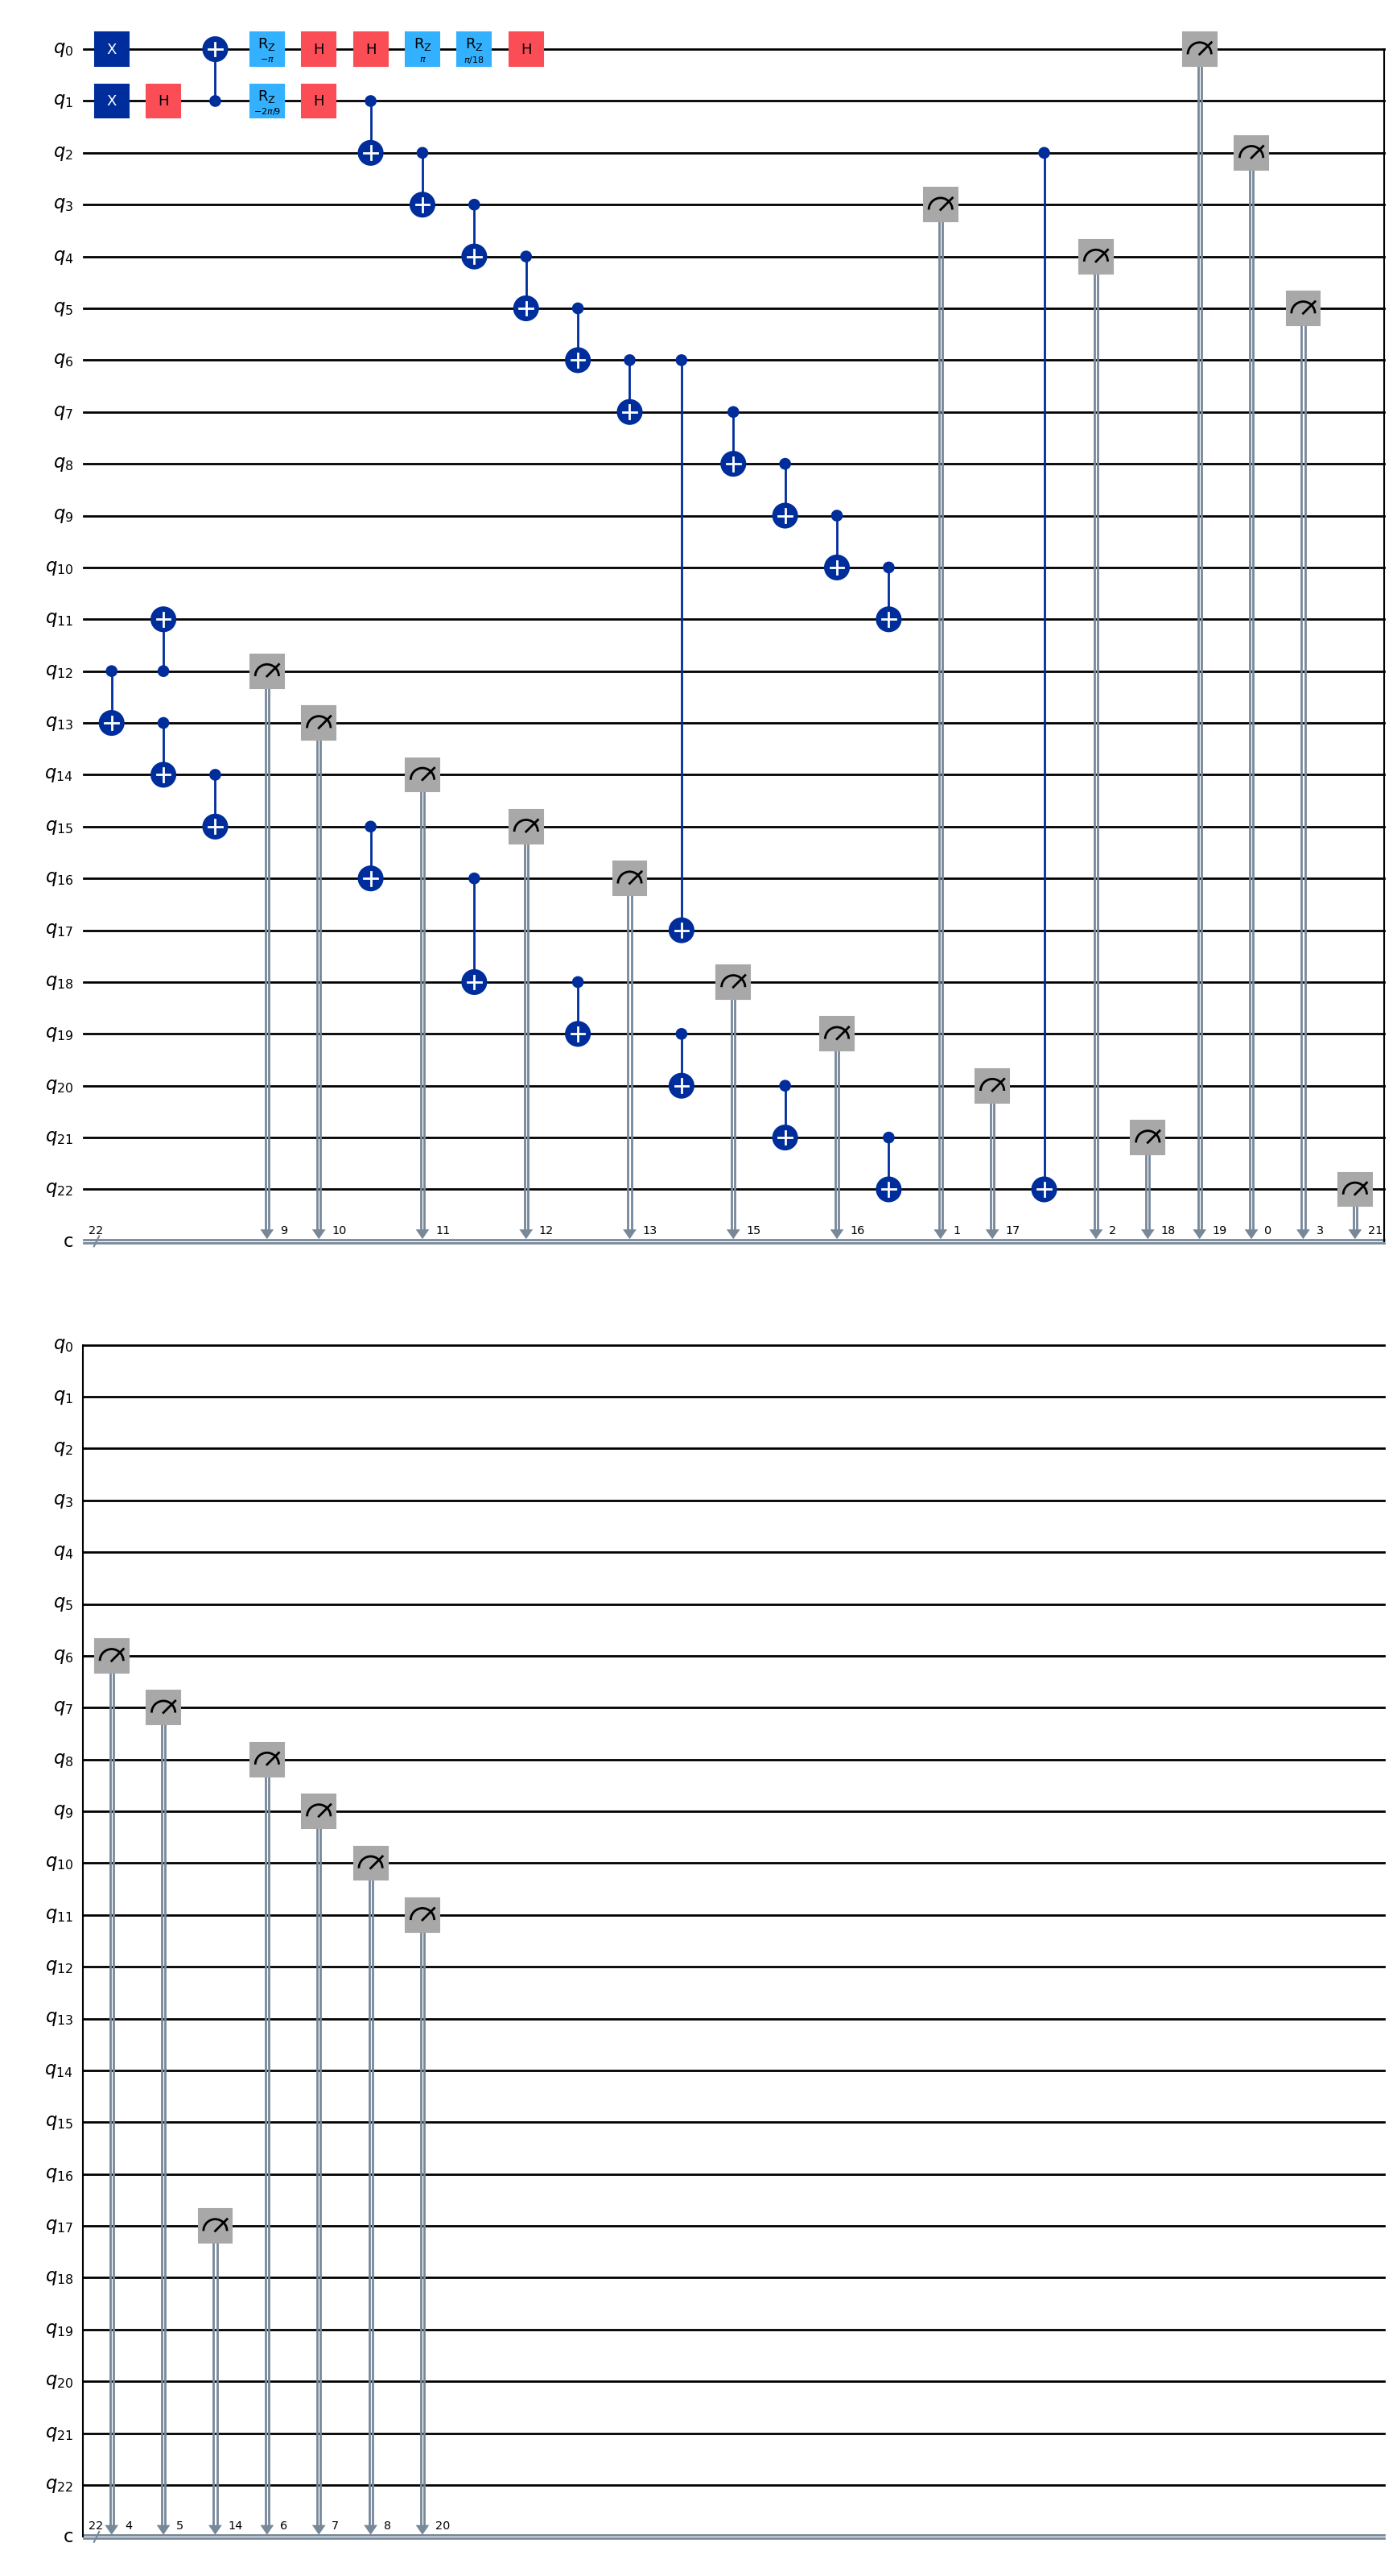

In [5]:
layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]

flags = [56, 58]

ewfs = EWFS(
    alice_setting=PEEK,
    bob_setting=REVERSE_1,
    coupling_map=coupling_map,
    layout=layout,
    flag_qubits=flags)
qc = ewfs.circuit()
qc.draw('mpl')

[0] [1] []


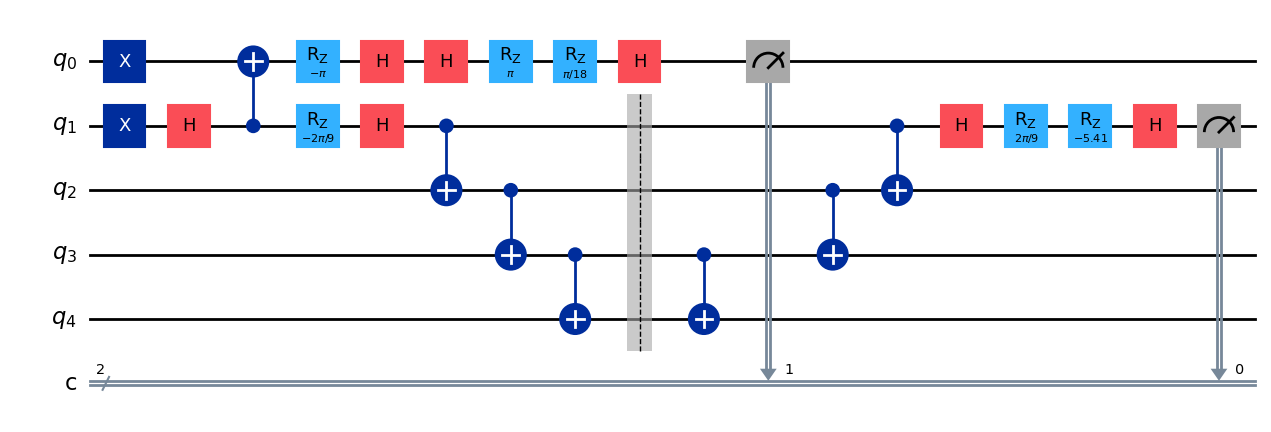

In [6]:
layout = [53, 52, 51, 50, 49]

flags = []

ewfs = EWFS(
    alice_setting=REVERSE_2,
    bob_setting=REVERSE_1,
    coupling_map=coupling_map,
    layout=layout,
    flag_qubits=flags)
qc = ewfs.circuit()
qc.draw('mpl')

In [8]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("aer_simulator")
settings = [(PEEK, REVERSE_1), (PEEK, REVERSE_2), (REVERSE_2, REVERSE_1), (REVERSE_2, REVERSE_2)]

semi_brukner_circuits = [EWFS(
    alice_setting=s1,
    bob_setting=s2,
    coupling_map=coupling_map,
    layout=layout,
    flag_qubits=flags).circuit() for s1, s2 in settings]

transpiled_circuits = [transpile(circuit, backend, optimization_level=3) for circuit in semi_brukner_circuits]

settings_circuits = dict(zip(settings, transpiled_circuits))

from qiskit_ibm_runtime import SamplerV2

sampler = SamplerV2(backend)

shots = 10_000
res = sampler.run(transpiled_circuits, shots=shots).result()

results = {}
i=0

for pub in res:
    print(pub.data.c.get_counts())
    probabilities = {key[::-1]: value / shots for key, value in pub.data.c.get_counts().items()}
    results[settings[i]] = probabilities
    i+=1
    

[0, 1, 2] [3] []
[0, 1, 2] [3] []
[0] [1] []
[0] [1] []
{'0111': 4154, '1000': 4058, '0000': 906, '1111': 882}
{'1111': 4153, '0000': 4068, '0111': 908, '1000': 871}
{'10': 4519, '11': 579, '01': 4314, '00': 588}
{'01': 4422, '10': 4413, '11': 572, '00': 593}


In [11]:
from ewfs import decode_results, post_select_results

charlie_size = len(layout) - len(flags) - 2
debbie_size = 0
flag_size = len(flags)

post_selected_results = post_select_results(results, charlie_size, flag_size)
dec_res = decode_results(post_selected_results, charlie_size=charlie_size)
dec_res

{('peek', 'reverse_1'): {'10': 0.4154,
  '01': 0.4058,
  '00': 0.0906,
  '11': 0.0882},
 ('peek', 'reverse_2'): {'11': 0.4153,
  '00': 0.4068,
  '10': 0.0908,
  '01': 0.0871},
 ('reverse_2', 'reverse_1'): {'01': 0.4519,
  '11': 0.0579,
  '10': 0.4314,
  '00': 0.0588},
 ('reverse_2', 'reverse_2'): {'10': 0.4422,
  '01': 0.4413,
  '11': 0.0572,
  '00': 0.0593}}

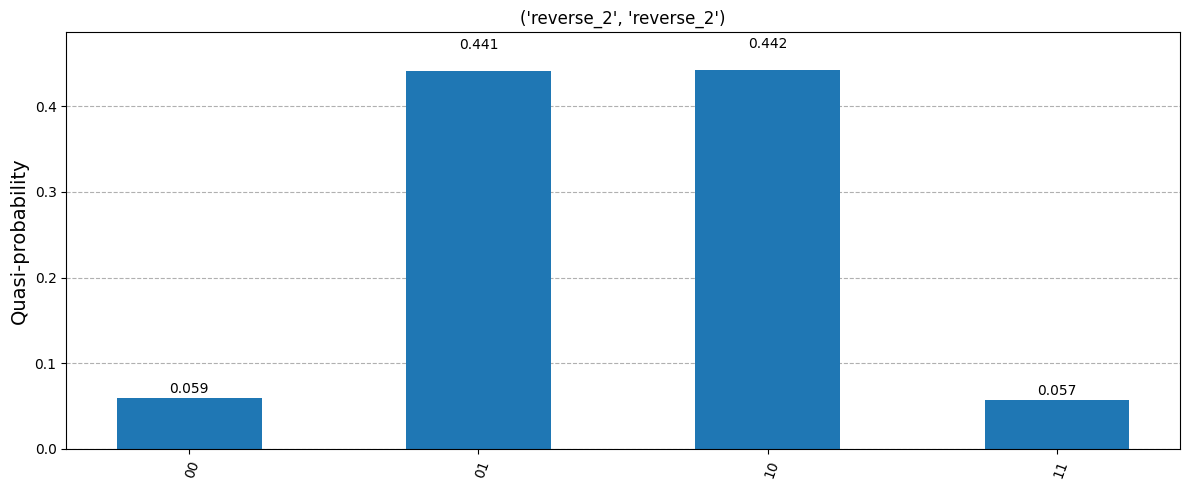

In [16]:
from qiskit.visualization import plot_distribution
i=3
setting, probs = settings[i], dec_res[settings[i]]
plot_distribution(probs, figsize=(12, 5), title=setting)
